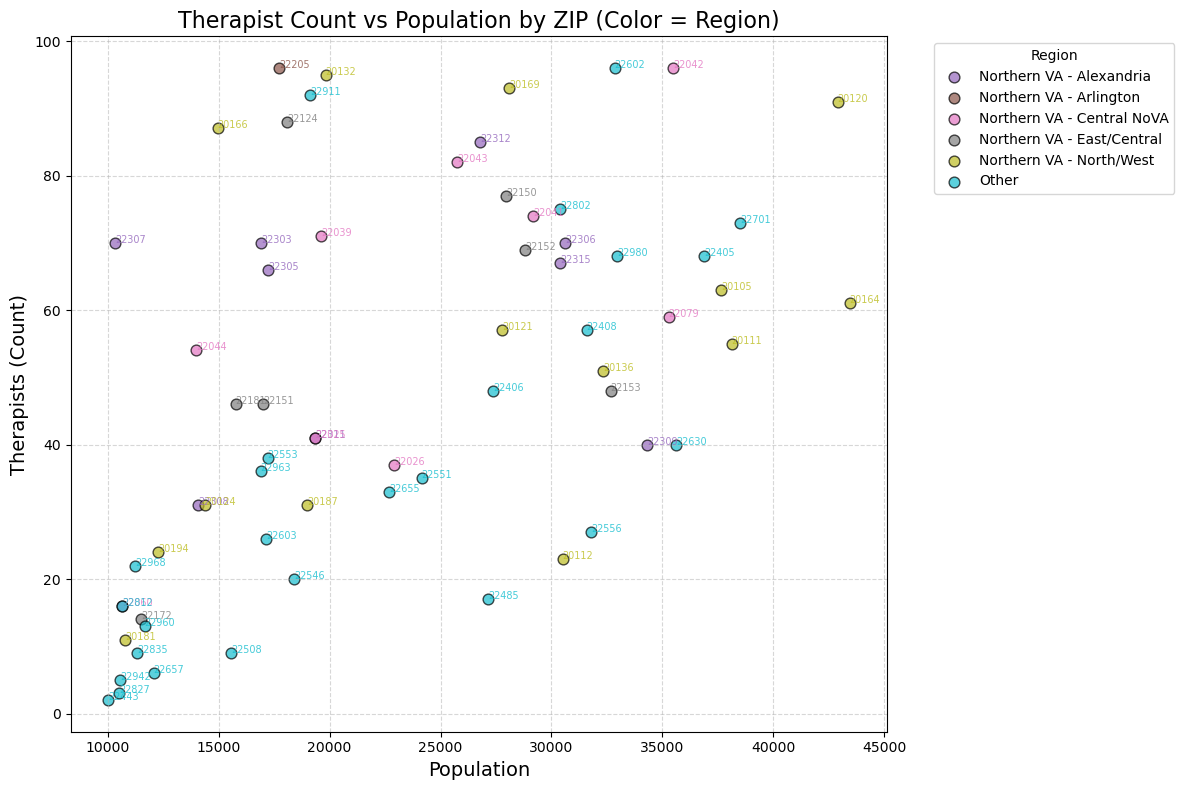

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load your combined CSV
df = pd.read_csv("combined_zip_population_therapists.csv")

# Filter: ZIP <= 23000, Count <= 100, Population > 500
df_plot = df[
    (df['Zip'].astype(int) <= 23000) &
    (df['Count'] <= 100) &
    (df['Population'] > 10000)
]

# Assign a color to each region
regions = sorted(df['Region'].unique())
region_to_color = {region: cm.get_cmap('tab10')(i % 10) for i, region in enumerate(regions)}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

for region, group in df_plot.groupby('Region'):
    ax.scatter(
        group['Population'],
        group['Count'],
        label=region,
        color=region_to_color[region],
        alpha=0.7,
        edgecolor='k',
        s=60
    )
    # Optionally, label each point with its ZIP code (can be crowded for large datasets)
    for _, row in group.iterrows():
        ax.text(
            row['Population'],
            row['Count'],
            str(row['Zip']),
            fontsize=7,
            color=region_to_color[region],
            alpha=0.8
        )

ax.set_xlabel("Population", fontsize=14)
ax.set_ylabel("Therapists (Count)", fontsize=14)
ax.set_title("Therapist Count vs Population by ZIP (Color = Region)", fontsize=16)
ax.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import csv

# --- Prepopulate filters here ---
MIN_POPULATION = 500
MAX_THERAPISTS = 100
MAX_ZIP = 23000
MIN_RATIO = 0  # Only show ZIPs with at least this pop/therapist ratio

# Load your combined CSV
df = pd.read_csv("combined_zip_population_therapists.csv")

# Load city/county info from census file
zip_info = {}
with open("census_data/virginia-zip-codes.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        zip_code = (row.get("zip") or "").strip().zfill(5)
        city = (row.get("city") or "").strip()
        county = (row.get("county") or "").strip()
        if zip_code:
            zip_info[zip_code] = (city, county)

# Apply filters
df_filtered = df[
    (df['Population'] > MIN_POPULATION) &
    (df['Count'] <= MAX_THERAPISTS) &
    (df['Zip'].astype(int) <= MAX_ZIP)
].copy()

# Avoid division by zero
df_filtered = df_filtered[df_filtered['Count'] > 0]

# Compute ratio
df_filtered['PopPerTherapist'] = df_filtered['Population'] / df_filtered['Count']

# Apply ratio filter if desired
df_filtered = df_filtered[df_filtered['PopPerTherapist'] >= MIN_RATIO]

# Group by region and sort within each region
regions = sorted(df_filtered['Region'].unique())

for region in regions:
    group = df_filtered[df_filtered['Region'] == region]
    group_sorted = group.sort_values('PopPerTherapist', ascending=False)
    if group_sorted.empty:
        continue
    print(f"\n=== {region} ===")
    for _, row in group_sorted.iterrows():
        zip_code = str(row['Zip']).zfill(5)
        city, county = zip_info.get(zip_code, ("", ""))
        #print(f"ZIP: {zip_code:<6}  City: {city:<20}  County: {county:<25}  Pop: {row['Population']:>7}  Therapists: {row['Count']:>4}  Pop/Therapist: {row['PopPerTherapist']:>8.2f}")
        #print(f"ZIP: {zip_code}, City: {city}, County: {county}, Pop: {row['Population']}, Therapists: {row['Count']}, Pop/Therapist: {row['PopPerTherapist']:.2f}")
        print(f"ZIP: {zip_code:<6}  City: {city:<20}  Pop: {row['Population']:>7}  Therapists: {row['Count']:>4}  Pop/Therapist: {row['PopPerTherapist']:>8.2f}")
        #print(f"ZIP: {zip_code}, City: {city}, Pop: {row['Population']}, Therapists: {row['Count']}, Pop/Therapist: {row['PopPerTherapist']:.2f}")


=== Northern VA - Alexandria ===
ZIP: 22309   City: Alexandria            Pop:   34316  Therapists:   40  Pop/Therapist:   857.90
ZIP: 22311   City: Alexandria            Pop:   19337  Therapists:   41  Pop/Therapist:   471.63
ZIP: 22308   City: Alexandria            Pop:   14090  Therapists:   31  Pop/Therapist:   454.52
ZIP: 22315   City: Alexandria            Pop:   30404  Therapists:   67  Pop/Therapist:   453.79
ZIP: 22306   City: Alexandria            Pop:   30602  Therapists:   70  Pop/Therapist:   437.17
ZIP: 22312   City: Alexandria            Pop:   26768  Therapists:   85  Pop/Therapist:   314.92
ZIP: 22305   City: Alexandria            Pop:   17214  Therapists:   66  Pop/Therapist:   260.82
ZIP: 22303   City: Alexandria            Pop:   16922  Therapists:   70  Pop/Therapist:   241.74
ZIP: 22307   City: Alexandria            Pop:   10343  Therapists:   70  Pop/Therapist:   147.76

=== Northern VA - Arlington ===
ZIP: 22213   City: Arlington             Pop:    4021  Thera